<a href="https://colab.research.google.com/github/ChungyiBossi/GjunDataAnaysis/blob/main/spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0803 問題探討


1.   目前用歌曲相似度(cos similarity) 去做推薦，但分數幾乎都非常接近(前幾名都接近0.99)
>   跟數值都是0~1正數有關
2.   推薦是否合理的驗證方式?
>   看推薦歌曲與原曲的類別重疊程度 +
>   盡量不要推跟原曲同一位歌手
3.   歌曲數過多會讓矩陣過於龐大，但大部分的資料並不會被重複使用到
4.   記憶體消耗過大
> 改用KNN

###### 0.Import Modules

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import itertools
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors

### 1.前處理

In [1]:
# Download latest version
# Change the output_dir to your desired location, e.g., '/content/drive/MyDrive/spotify_data'
path = kagglehub.dataset_download(
    "joebeachcapital/30000-spotify-songs",
    output_dir='/content/drive/MyDrive/spotify_data'
)
print("Path to dataset files:", path)
df = pd.read_csv(path + "/spotify_songs.csv" )
df.head()


100%|██████████| 3.01M/3.01M [00:00<00:00, 101MB/s]

Extracting files...
Path to dataset files: /content/drive/MyDrive/spotify_data


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

In [3]:
print(f"Original DataFrame shape before new deduplication: {df.shape}")

# Handle potential missing values in critical columns
# Fill with 'Unknown' to ensure they can be grouped and counted
df['track_name'] = df['track_name'].fillna('Unknown Track')
df['track_artist'] = df['track_artist'].fillna('Unknown Artist')
df['playlist_genre'] = df['playlist_genre'].fillna('Unknown Genre')

# Identify duplicate songs based on name and artist
# For each group of duplicates, find the most frequent genre
# First, count genre occurrences within each (track_name, track_artist) group
genre_counts = df.groupby(['track_name', 'track_artist', 'playlist_genre']).size().reset_index(name='genre_occurrence_count')

# Merge this count back to the original dataframe
df = df.merge(genre_counts, on=['track_name', 'track_artist', 'playlist_genre'], how='left')

# Now, sort to prioritize the genre with the highest occurrence count, then by track_popularity
df = df.sort_values(by=['genre_occurrence_count', 'track_popularity'], ascending=[False, False])

# Drop duplicates based on 'track_name' and 'track_artist', keeping the first (most frequent genre, then highest popularity)
df = df.drop_duplicates(subset=['track_name', 'track_artist'], keep='first')

# Drop the temporary 'genre_occurrence_count' column
df = df.drop(columns=['genre_occurrence_count'])

print(f"DataFrame shape after removing duplicate songs (most frequent genre first, then highest popularity): {df.shape}")
df.head()

Original DataFrame shape before new deduplication: (32833, 23)
DataFrame shape after removing duplicate songs (most frequent genre first, then highest popularity): (26230, 23)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
11258,7o2CTH4ctstm8TNelqjb51,Sweet Child O' Mine,Guns N' Roses,82,3I9Z1nDCL4E0cP62flcbI5,Appetite For Destruction,1987-01-01,This Is Guns N' Roses,37i9dQZF1DX74DnfGTwugU,rock,...,6,-7.766,1,0.0446,0.0852,0.098800,0.1160,0.630,125.116,354520
12263,7e89621JPkKaeDSTQ3avtg,Sweet Home Alabama,Lynyrd Skynyrd,81,54V1ljNtyzAm053oJqi0SH,Second Helping,1974-04-15,The Sound of Album Rock,3yj9YnQGTdnFuKbDyXGDi6,rock,...,7,-12.145,1,0.0255,0.1810,0.000331,0.0863,0.886,97.798,283800
11255,0bVtevEgtDIeRjCJbK3Lmv,Welcome To The Jungle,Guns N' Roses,78,3I9Z1nDCL4E0cP62flcbI5,Appetite For Destruction,1987-01-01,This Is Guns N' Roses,37i9dQZF1DX74DnfGTwugU,rock,...,8,-8.069,1,0.0764,0.0232,0.395000,0.2970,0.332,123.450,272027
12793,2KH16WveTQWT6KOG9Rg6e2,Eye of the Tiger,Survivor,76,3t3BbpFJiGcXl4jI5CRLLA,Rocky IV,1985,Supernatural Classic Rock,6oghIlByD49KFGNmNU8GSH,rock,...,0,-9.249,0,0.0328,0.1320,0.000311,0.0873,0.548,108.873,245640
13753,37ZJ0p5Jm13JPevGcx4SkF,Livin' On A Prayer,Bon Jovi,83,0kBfgEilUFCMIQY5IOjG4t,Slippery When Wet,1986-01-01,Permanent wave,0tOy7ZY4E2PadXIyj8zU43,rock,...,0,-3.757,1,0.0335,0.0778,0.000214,0.2940,0.795,122.511,249293


In [5]:
# numerical_features = df.select_dtypes(["int64", "float64"]).columns.tolist()
# numerical_features.remove('track_popularity')
# numerical_features.remove('duration_ms')
# numerical_features
numerical_features = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_minutes',
]

In [6]:

# Define categorical features to use
# 用作下一階段判斷/baseline?
categorical_features = ['playlist_genre', 'playlist_subgenre']

# First, ensure 'release_year' and 'release_month' and 'duration_minutes' are created
def get_year_and_month(datecode):
    if not isinstance(datecode, str):
        return pd.Series((1900, 1))
    YMD = datecode.split('-')
    if len(YMD) >= 2:
        return pd.Series((int(YMD[0]), int(YMD[1])))
    elif len(YMD) == 1:
        return pd.Series((int(YMD[0]), 1))
    else:
        return pd.Series((1900, 1))

In [7]:
df[['release_year', 'release_month']] = df['track_album_release_date'].apply(get_year_and_month)
df['duration_minutes'] = round(df['duration_ms']/60000, 2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26230 entries, 11258 to 32822
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  26230 non-null  object 
 1   track_name                26230 non-null  object 
 2   track_artist              26230 non-null  object 
 3   track_popularity          26230 non-null  int64  
 4   track_album_id            26230 non-null  object 
 5   track_album_name          26229 non-null  object 
 6   track_album_release_date  26230 non-null  object 
 7   playlist_name             26230 non-null  object 
 8   playlist_id               26230 non-null  object 
 9   playlist_genre            26230 non-null  object 
 10  playlist_subgenre         26230 non-null  object 
 11  danceability              26230 non-null  float64
 12  energy                    26230 non-null  float64
 13  key                       26230 non-null  int64  
 14  loudnes

In [9]:
# from google.colab import drive
# drive.mount('/content/drive')

In [10]:
df.to_csv('/content/drive/MyDrive/spotify_data/modified_spotify_30000.csv')

### 2.使用 KNN 替代cos similarity matrix

In [11]:

df_recs_knn = df.copy() # 保險起見複製一份

# Handle potential missing values in categorical columns before encoding
for col in categorical_features:
    df_recs_knn[col] = df_recs_knn[col].fillna('unknown')

# 1. Scale numerical features
scaler = MinMaxScaler()
df_recs_knn[numerical_features] = scaler.fit_transform(df_recs_knn[numerical_features])
df_recs_knn[numerical_features].head(10)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_minutes
11258,0.461851,0.909984,0.810553,0.048584,0.085714,0.099396,0.116466,0.636364,0.522536,0.682243
12263,0.606307,0.604931,0.718794,0.027778,0.182093,0.000333,0.086647,0.894949,0.408445,0.544393
11255,0.453713,0.953992,0.804203,0.083224,0.023340,0.397384,0.298193,0.335354,0.515578,0.521028
12793,0.831129,0.598930,0.779477,0.035730,0.132797,0.000313,0.087651,0.553535,0.454698,0.469626
13753,0.541200,0.886980,0.894558,0.036492,0.078270,0.000215,0.295181,0.803030,0.511656,0.476636
11253,0.277721,0.951992,0.789682,0.091612,0.017002,0.011268,0.142570,0.479798,0.418765,0.781542
12209,0.556460,0.690946,0.689290,0.040196,0.015091,0.105634,0.144578,0.673737,0.572787,0.502336
12582,0.651068,0.662941,0.815791,0.040741,0.202213,0.008109,0.152610,0.669697,0.554502,0.266355
12206,0.367243,0.969995,0.872347,0.309368,0.001700,0.001640,0.358434,0.256566,0.747649,0.543224
12277,0.497457,0.723952,0.797959,0.038344,0.314889,0.186117,0.288153,0.151515,0.489860,0.577103


In [12]:
# 2. Fit NearestNeighbors model
# Using cosine metric for similarity in KNN ( return cosine_distance = 1 - cos_similarity )
model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn.fit(df_recs_knn[numerical_features])

print("KNN model trained successfully.")

KNN model trained successfully.


#### 2-1. 儲存已完成的模型

In [13]:
# Define the path to save the model
model_save_path = '/content/drive/MyDrive/spotify_data/knn_model.joblib'

# Save the KNN model
joblib.dump(model_knn, model_save_path)
print(f"KNN model saved to: {model_save_path}")

KNN model saved to: /content/drive/MyDrive/spotify_data/knn_model.joblib


#### 2-2.讀取模型

In [14]:
# Load the KNN model
loaded_model_knn = joblib.load(model_save_path)
print(f"KNN model loaded from: {model_save_path}")

KNN model loaded from: /content/drive/MyDrive/spotify_data/knn_model.joblib


#### 2-3.取得推薦

In [15]:
def recommend_songs_knn(song_name, dataframe, model, feature_list, num_recommendations=10):
    # Get the index of the song that matches the song_name
    try:
        idx = dataframe[dataframe['track_name'].str.contains(song_name, case=False, na=False)].index[0]
    except IndexError:
        print(f"Song '{song_name}' not found in the dataset. Please try another song.")
        return pd.DataFrame()

    # Get the feature vector for the input song
    song_features = dataframe[feature_list].loc[[idx]]

    # Find the nearest neighbors
    distances, indices = model.kneighbors(song_features, n_neighbors=num_recommendations + 1)

    # Flatten the arrays
    distances = distances.flatten() # 距離
    indices = indices.flatten() # 編號

    # Create a list of (index, distance) tuples, excluding the song itself (distance[0] will be 0)
    sim_scores = []
    for i in range(1, len(distances)): # Start from 1 to exclude the input song itself
        sim_scores.append((indices[i], 1 - distances[i])) # Convert distance to similarity

    # Get the song indices and similarity scores
    song_indices = [s[0] for s in sim_scores]
    similarity_values = [s[1] for s in sim_scores]

    # Return the top N most similar songs, including all numerical features
    # Also include other relevant metadata for analysis (genre, artist, etc.)
    df_n_similar = dataframe.iloc[song_indices][['track_name', 'track_artist', 'track_popularity', 'playlist_genre', 'playlist_subgenre'] + feature_list]
    df_n_similar['similarity_score'] = similarity_values

    # Remove Duplicate Tracks by name, keeping the one with higher similarity if any
    df_n_similar = df_n_similar.sort_values(by='similarity_score', ascending=False)

    return df_n_similar

In [16]:
# Demo: Get recommendations for 'Someone You Loved' using KNN
original_song_name = 'Someone You Loved'
print("\nDemo: Getting recommendations for 'Someone You Loved' using KNN:")
recommended_tracks_knn = recommend_songs_knn(
    original_song_name,
    df_recs_knn,
    model_knn,
    numerical_features,
    num_recommendations=20
)
print(len(recommended_tracks_knn))
display(recommended_tracks_knn)


Demo: Getting recommendations for 'Someone You Loved' using KNN:
20


,track_name,track_artist,track_popularity,playlist_genre,playlist_subgenre,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_minutes,similarity_score
745,nana triste,Natalia Lacunza,59,pop,dance pop,0.482197,0.307879,0.776083,0.062418,0.766600,0.000000,0.111446,0.422222,0.389839,0.356308,0.996785
26727,The Greatest,Cat Power,60,r&b,neo soul,0.516785,0.361888,0.770278,0.028540,0.742455,0.001004,0.092570,0.331313,0.448793,0.386682,0.995919
1535,Favorite Part Of Me,Astrid S,70,pop,post-teen pop,0.608342,0.501913,0.841837,0.048693,0.867203,0.000000,0.096386,0.407071,0.507939,0.378505,0.995560
18004,Cuts Both Ways,Gloria Estefan,41,latin,latin pop,0.386572,0.308879,0.709260,0.035839,0.652918,0.000000,0.073594,0.302020,0.349641,0.369159,0.994981
17845,Amor Genuino,Ozuna,59,latin,latin pop,0.449644,0.444903,0.887979,0.041503,0.656942,0.000000,0.118474,0.427273,0.358102,0.342290,0.994901
22368,I'd Rather Go Blind - Live,Dua Lipa,60,r&b,urban contemporary,0.576806,0.346886,0.857343,0.037364,0.686117,0.000001,0.087651,0.351515,0.476345,0.296729,0.994840
26766,Will You Love Me Tomorrow,The Shirelles,35,r&b,neo soul,0.516785,0.501913,0.865893,0.035076,0.709256,0.000047,0.145582,0.494949,0.569700,0.307243,0.994614
1461,What A Time (feat. Niall Horan),Julia Michaels,78,pop,post-teen pop,0.526958,0.466907,0.843702,0.032898,0.665996,0.000000,0.085643,0.389899,0.554853,0.329439,0.994300
22516,The Only Way Out,Andra Day,39,r&b,urban contemporary,0.507630,0.336884,0.786874,0.046623,0.747485,0.000000,0.120482,0.378788,0.353187,0.427570,0.994179
22338,Why,Skinny Living,56,r&b,urban contemporary,0.531027,0.502913,0.843409,0.059150,0.722334,0.000003,0.093876,0.370707,0.555016,0.331776,0.994056


### 3.驗證推薦結果-是否為相似的歌曲?

In [17]:
original_song_name

'Someone You Loved'

In [18]:
# Get the genre and subgenre of the original song
# Use '==' for an exact match of the song name
original_song_info = df[df['track_name'] == original_song_name].iloc[0]
display(original_song_info[['track_name', 'track_artist', 'playlist_genre', 'playlist_subgenre']])

,718
track_name,Someone You Loved
track_artist,Lewis Capaldi
playlist_genre,pop
playlist_subgenre,dance pop


In [19]:

# Display the recommended songs along with their genre and subgenre
display(recommended_tracks_knn[['track_name', 'track_artist', 'playlist_genre', 'playlist_subgenre', 'similarity_score']])


,track_name,track_artist,playlist_genre,playlist_subgenre,similarity_score
745,nana triste,Natalia Lacunza,pop,dance pop,0.996785
26727,The Greatest,Cat Power,r&b,neo soul,0.995919
1535,Favorite Part Of Me,Astrid S,pop,post-teen pop,0.995560
18004,Cuts Both Ways,Gloria Estefan,latin,latin pop,0.994981
17845,Amor Genuino,Ozuna,latin,latin pop,0.994901
22368,I'd Rather Go Blind - Live,Dua Lipa,r&b,urban contemporary,0.994840
26766,Will You Love Me Tomorrow,The Shirelles,r&b,neo soul,0.994614
1461,What A Time (feat. Niall Horan),Julia Michaels,pop,post-teen pop,0.994300
22516,The Only Way Out,Andra Day,r&b,urban contemporary,0.994179
22338,Why,Skinny Living,r&b,urban contemporary,0.994056


#### 3-1. Genre Overlapping

In [20]:
display(original_song_info)

,718
track_id,7qEHsqek33rTcFNT9PFqLf
track_name,Someone You Loved
track_artist,Lewis Capaldi
track_popularity,94
track_album_id,5658aM19fA3JVwTK6eQX70
track_album_name,Divinely Uninspired To A Hellish Extent
track_album_release_date,2019-05-17
playlist_name,Todo Éxitos
playlist_id,2ji5tRQVfnhaX1w9FhmSzk
playlist_genre,pop


In [21]:
original_genre = original_song_info['playlist_genre']
original_subgenre = original_song_info['playlist_subgenre']

print(f"Original Song: '{original_song_name}'")
print(f"Original Genre: {original_genre}")
print(f"Original Subgenre: {original_subgenre}\n")
# Count overlap
genre_overlap_count = (recommended_tracks_knn['playlist_genre'] == original_genre).sum()
subgenre_overlap_count = (recommended_tracks_knn['playlist_subgenre'] == original_subgenre).sum()

print(f"同父類型  ('{original_genre}'): {genre_overlap_count}")
print(f"同子類型 ('{original_subgenre}'): {subgenre_overlap_count}")

Original Song: 'Someone You Loved'
Original Genre: pop
Original Subgenre: dance pop

同父類型  ('pop'): 5
同子類型 ('dance pop'): 1


#### 3-2. Artist Overlapping

In [22]:
original_artist = original_song_info['track_artist']
print(f"Original Song Artist: '{original_artist}'")

artist_overlap_count = (recommended_tracks_knn['track_artist'] == original_artist).sum()
print(f"Number of recommended tracks by the original artist ('{original_artist}'): {artist_overlap_count}")

Original Song Artist: 'Lewis Capaldi'
Number of recommended tracks by the original artist ('Lewis Capaldi'): 0


#### 3-3. Artist Diversity

In [23]:

unique_artist_songs = recommended_tracks_knn.drop_duplicates(subset=['track_name', 'track_artist'])
different_artist = len(unique_artist_songs['track_artist'].unique())

print(f"Artists Diversity = {different_artist/len(unique_artist_songs)*100}%")

Artists Diversity = 100.0%


/tmp/ipykernel_1759/4277125126.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


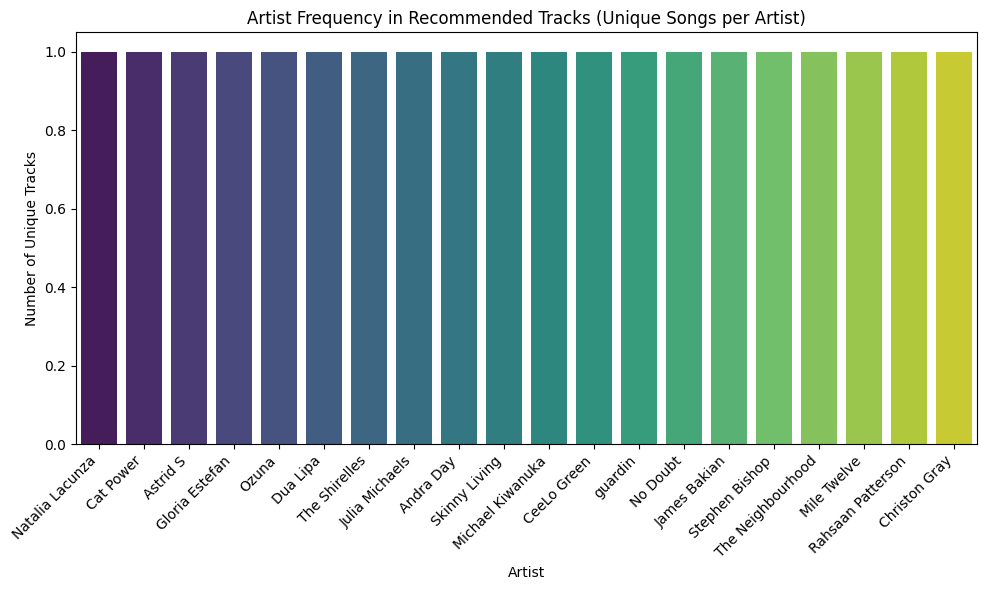

In [24]:
# Create a temporary DataFrame to handle duplicates for frequency calculation
# Drop duplicates based on 'track_name' and 'track_artist' to treat them as one unique song by that artist
unique_artist_songs = recommended_tracks_knn.drop_duplicates(subset=['track_name', 'track_artist'])

artist_frequency = unique_artist_songs['track_artist'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=artist_frequency.index,
    y=artist_frequency.values,
    palette='viridis',
    legend=False
)
plt.title('Artist Frequency in Recommended Tracks (Unique Songs per Artist)')
plt.xlabel('Artist')
plt.ylabel('Number of Unique Tracks')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 3-4.特徵值判斷

In [25]:
# Get the original song's scaled numerical features
# This makes original_song_scaled_features available for all subsequent feature difference calculations
original_song_scaled_features = df_recs_knn[numerical_features].loc[[original_song_info.name]]


In [26]:
print(f"Original Song: {original_song_name}")
# Displaying the SCALED original song features for consistency with the average recommended features
print("Original Song SCALED Features:")
display(original_song_scaled_features)

print("\nAverage Features of Recommended Tracks:")
average_recommended_features = recommended_tracks_knn[numerical_features].mean()
display(average_recommended_features)

print("\nFeature Difference (Original SCALED vs. Average Recommended SCALED):")
# Correctly calculate feature_difference using the scaled original song features
feature_difference = (original_song_scaled_features - average_recommended_features).abs().T.squeeze()
display(feature_difference)

Original Song: Someone You Loved
Original Song SCALED Features:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_minutes
718,0.509664,0.404896,0.854284,0.034749,0.755533,0.0,0.105422,0.450505,0.45895,0.346963



Average Features of Recommended Tracks:


,0
danceability,0.544863
energy,0.413747
loudness,0.817901
speechiness,0.041111
acousticness,0.736167
instrumentalness,0.000066
liveness,0.111135
valence,0.421818
tempo,0.449260
duration_minutes,0.373072



Feature Difference (Original SCALED vs. Average Recommended SCALED):


,718
danceability,0.035198
energy,0.008852
loudness,0.036383
speechiness,0.006362
acousticness,0.019366
instrumentalness,0.000066
liveness,0.005713
valence,0.028687
tempo,0.009690
duration_minutes,0.026110


沒有判斷基準可以考慮以下當Baseline

1.   跟隨機推薦比較
2.   比較不同模型
3.   比較不同 Feature 組合



##### 3-4-1. 跟隨機推薦比較

In [27]:
# 1. Generate Random Recommendations (same number as KNN recommendations)
num_random_recommendations = len(recommended_tracks_knn)
random_indices = np.random.choice(df_recs_knn.index, num_random_recommendations, replace=False)
random_tracks = df_recs_knn.loc[random_indices]

print("\n隨機推薦歌曲範例 (Random Recommended Tracks Sample):")
display(random_tracks[['track_name', 'track_artist', 'playlist_genre', 'playlist_subgenre']].head())

# 2. Calculate Average Features of Random Recommendations
average_random_features = random_tracks[numerical_features].mean()

# 3. Calculate Feature Difference (Original vs. Average Random)
random_feature_difference = (original_song_scaled_features - average_random_features).abs().T.squeeze()


print("\n--- 比較摘要 ---")
print("KNN 推薦的特徵差異 (Feature Difference - KNN Recommendations):")
display(feature_difference)
print("\n隨機推薦的特徵差異 (Feature Difference - Random Recommendations):")
display(random_feature_difference)


隨機推薦歌曲範例 (Random Recommended Tracks Sample):


,track_name,track_artist,playlist_genre,playlist_subgenre
15473,The Line,Foo Fighters,rock,hard rock
31256,If You Were,Danny Howard,edm,progressive electro house
858,Through People Like Me - Chris Howland Remix,Mass Anthem,pop,dance pop
20209,Pipa - Pep & Rash Remix,Santos Suarez,latin,latin hip hop
5099,Road Trip,chloe moriondo,pop,indie poptimism



--- 比較摘要 ---
KNN 推薦的特徵差異 (Feature Difference - KNN Recommendations):


,718
danceability,0.035198
energy,0.008852
loudness,0.036383
speechiness,0.006362
acousticness,0.019366
instrumentalness,0.000066
liveness,0.005713
valence,0.028687
tempo,0.009690
duration_minutes,0.026110



隨機推薦的特徵差異 (Feature Difference - Random Recommendations):


,718
danceability,0.104120
energy,0.314305
loudness,0.053734
speechiness,0.043382
acousticness,0.560282
instrumentalness,0.235363
liveness,0.040612
valence,0.037970
tempo,0.036171
duration_minutes,0.063727


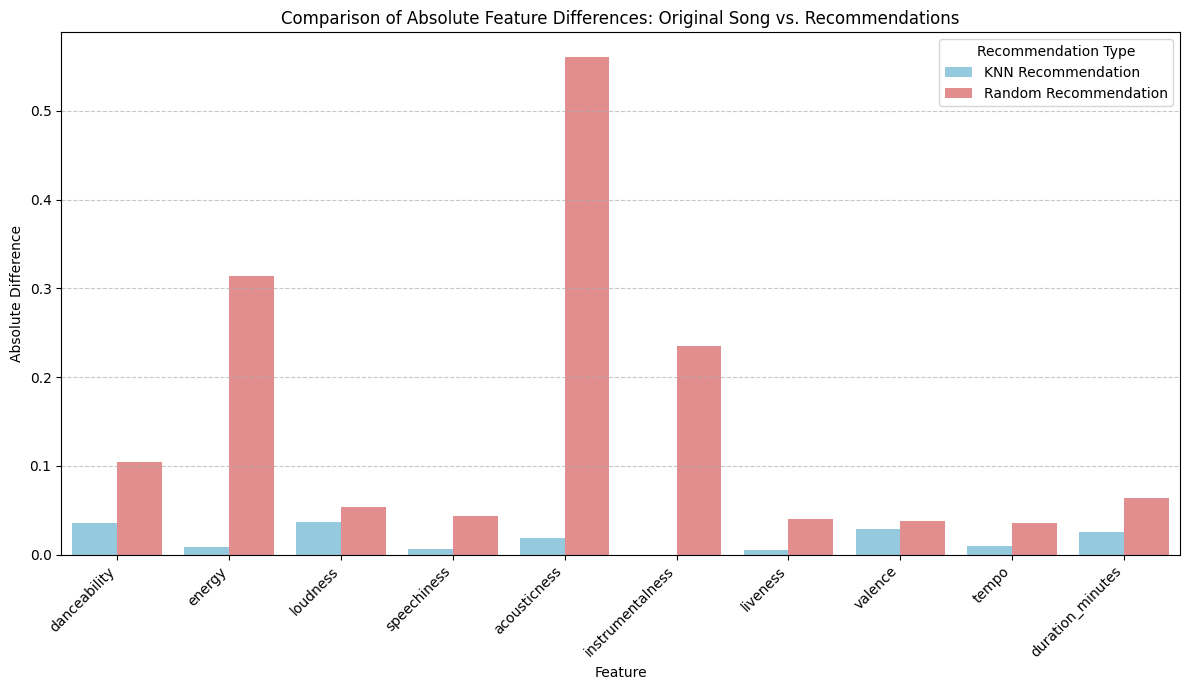

In [28]:
# 繪製 KNN 與隨機推薦的特徵差異比較長條圖

import matplotlib.pyplot as plt
import seaborn as sns

# Combine the feature differences into a single DataFrame for plotting
comparison_df = pd.DataFrame({
    'KNN Recommendation': feature_difference,
    'Random Recommendation': random_feature_difference
})

# Plotting the comparison
plt.figure(figsize=(12, 7))
sns.barplot(data=comparison_df.reset_index().melt(id_vars='index', var_name='Recommendation Type', value_name='Absolute Feature Difference'),
            x='index',
            y='Absolute Feature Difference',
            hue='Recommendation Type',
            palette={'KNN Recommendation': 'skyblue', 'Random Recommendation': 'lightcoral'})

plt.title('Comparison of Absolute Feature Differences: Original Song vs. Recommendations')
plt.xlabel('Feature')
plt.ylabel('Absolute Difference')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 3-4-2. 同類型歌曲的隨機

In [29]:
# 1. Generate Random Recommendations (same number as KNN recommendations)
num_random_recommendations = len(recommended_tracks_knn)
same_genre_indices = df_recs_knn[
    (df_recs_knn['playlist_genre'] == original_genre) &
    (df_recs_knn['playlist_subgenre'] == original_subgenre)
].index
random_indices = np.random.choice(same_genre_indices, num_random_recommendations, replace=False)
random_tracks = df_recs_knn.loc[random_indices]

print("\n隨機推薦同類歌曲範例 (Random Recommended Tracks Sample):")
display(random_tracks[['track_name', 'track_artist', 'playlist_genre', 'playlist_subgenre']].head())

# 2. Calculate Average Features of Random Recommendations
average_random_features_same_genre = random_tracks[numerical_features].mean()

# 3. Calculate Feature Difference (Original vs. Average Random)
random_feature_difference = (original_song_scaled_features - average_random_features_same_genre).abs().T.squeeze()


print("\n--- 比較摘要 ---")
print("KNN 推薦的特徵差異 (Feature Difference - KNN Recommendations):")
display(feature_difference)
print("\n隨機推薦同類歌曲的特徵差異 (Feature Difference - Same Genre Random Recommendations):")
display(random_feature_difference)


隨機推薦同類歌曲範例 (Random Recommended Tracks Sample):


,track_name,track_artist,playlist_genre,playlist_subgenre
615,Unbelievable,Andrew Roman,pop,dance pop
952,The Weekend,REK,pop,dance pop
1241,Uptown Funk,Mark Ronson,pop,dance pop
422,SPOTLIGHT,eill,pop,dance pop
361,Skyline,Catiso,pop,dance pop



--- 比較摘要 ---
KNN 推薦的特徵差異 (Feature Difference - KNN Recommendations):


,718
danceability,0.035198
energy,0.008852
loudness,0.036383
speechiness,0.006362
acousticness,0.019366
instrumentalness,0.000066
liveness,0.005713
valence,0.028687
tempo,0.009690
duration_minutes,0.026110



隨機推薦同類歌曲的特徵差異 (Feature Difference - Same Genre Random Recommendations):


,718
danceability,0.191251
energy,0.320456
loudness,0.003196
speechiness,0.054548
acousticness,0.585189
instrumentalness,0.101637
liveness,0.050040
valence,0.046364
tempo,0.000048
duration_minutes,0.030315


In [30]:
num_iterations = 50
all_random_feature_differences = []

for _ in range(num_iterations):
    # 1. Generate Random Recommendations (same number as KNN recommendations)
    num_random_recommendations = len(recommended_tracks_knn)
    same_genre_indices = df_recs_knn[
        (df_recs_knn['playlist_genre'] == original_genre) &
        (df_recs_knn['playlist_subgenre'] == original_subgenre)
    ].index

    # Ensure there are enough songs in the same genre/subgenre to pick from
    if len(same_genre_indices) < num_random_recommendations:
        print(f"Warning: Not enough songs in the same genre/subgenre for {num_random_recommendations} recommendations. Using all available.")
        random_indices = same_genre_indices.to_numpy() # Convert to numpy array if it's a pandas index
    else:
        random_indices = np.random.choice(same_genre_indices, num_random_recommendations, replace=False)

    random_tracks = df_recs_knn.loc[random_indices]

    # 2. Calculate Average Features of Random Recommendations
    average_random_features_same_genre_iteration = random_tracks[numerical_features].mean()

    # 3. Calculate Feature Difference (Original vs. Average Random)
    random_feature_difference_iteration = (original_song_scaled_features - average_random_features_same_genre_iteration).abs().T.squeeze()
    all_random_feature_differences.append(random_feature_difference_iteration)

# Average the feature differences over all iterations
average_random_feature_difference_overall = pd.DataFrame(all_random_feature_differences).mean()

print(f"\n--- 比較摘要 ({num_iterations}次隨機推薦平均) ---")
print("KNN 推薦的特徵差異 (Feature Difference - KNN Recommendations):")
display(feature_difference)
print(f"\n隨機推薦同類歌曲的平均特徵差異 (Average Feature Difference - {num_iterations} Same Genre Random Recommendations):")
display(average_random_feature_difference_overall)


--- 比較摘要 (50次隨機推薦平均) ---
KNN 推薦的特徵差異 (Feature Difference - KNN Recommendations):


,718
danceability,0.035198
energy,0.008852
loudness,0.036383
speechiness,0.006362
acousticness,0.019366
instrumentalness,0.000066
liveness,0.005713
valence,0.028687
tempo,0.009690
duration_minutes,0.026110



隨機推薦同類歌曲的平均特徵差異 (Average Feature Difference - 50 Same Genre Random Recommendations):


,0
danceability,0.150790
energy,0.343837
loudness,0.007209
speechiness,0.048003
acousticness,0.622628
instrumentalness,0.055759
liveness,0.068535
valence,0.054081
tempo,0.039568
duration_minutes,0.048422


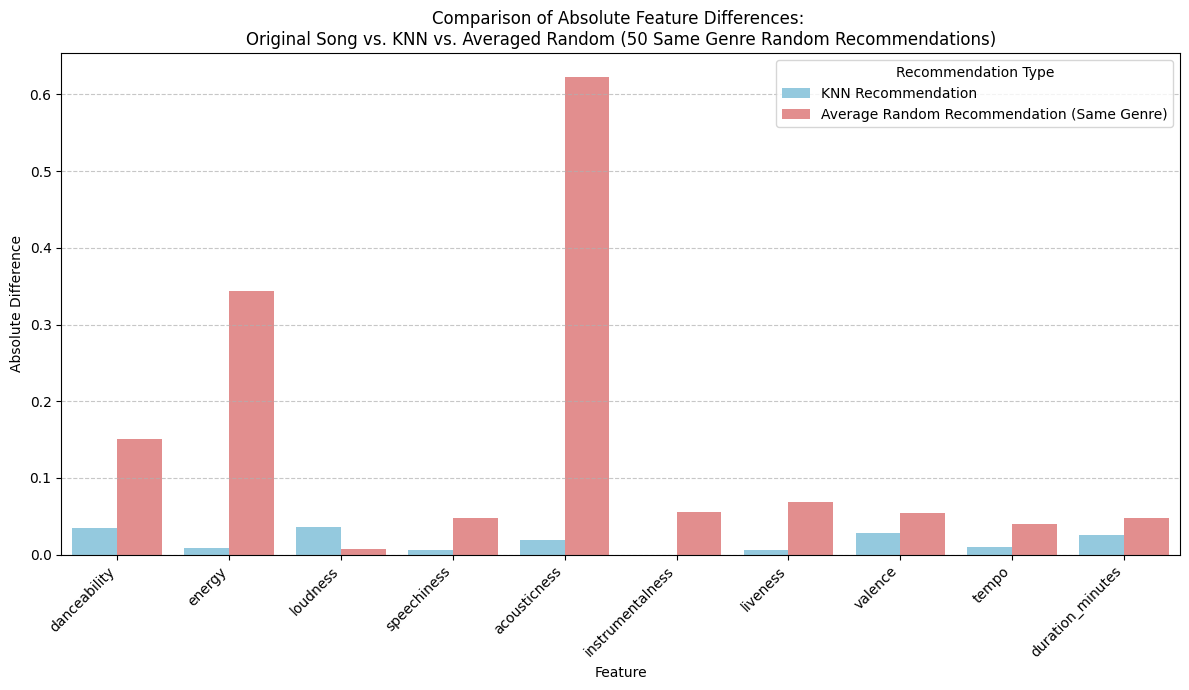

In [31]:
# 繪製 KNN 與平均隨機推薦的特徵差異比較長條圖

import matplotlib.pyplot as plt
import seaborn as sns

# Combine the feature differences into a single DataFrame for plotting
comparison_df_avg_random = pd.DataFrame({
    'KNN Recommendation': feature_difference,
    'Average Random Recommendation (Same Genre)': average_random_feature_difference_overall
})

# Plotting the comparison
plt.figure(figsize=(12, 7))
sns.barplot(
    data=comparison_df_avg_random.reset_index().melt(
        id_vars='index',
        var_name='Recommendation Type',
        value_name='Absolute Feature Difference'),
    x='index',
    y='Absolute Feature Difference',
    hue='Recommendation Type',
    palette={'KNN Recommendation': 'skyblue', 'Average Random Recommendation (Same Genre)': 'lightcoral'})

plt.title(f'Comparison of Absolute Feature Differences: \nOriginal Song vs. KNN vs. Averaged Random ({num_iterations} Same Genre Random Recommendations)')
plt.xlabel('Feature')
plt.ylabel('Absolute Difference')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 3-4-2. 參數調整

###### 找到最好的K，並把difference分布畫出來

In [77]:

# Define the range of k (number of neighbors) to search
k_values = range(5, 51, 5) # Test k from 5 to 50 with step 5

results = []

print("Performing Grid Search for optimal k...")

for k in k_values:
    # Find the nearest neighbors for the original song
    # We need k+1 neighbors because the first one will be the song itself
    distances, indices = model_knn.kneighbors(original_song_scaled_features, n_neighbors=k + 1)

    # Get the indices of the recommended songs (excluding the original song itself)
    # indices[0] contains the indices for the first (and only) query song
    recommended_indices = indices[0][1:] # Exclude the first index (original song)

    # Get the recommended tracks
    recommended_tracks = df_recs_knn.iloc[recommended_indices]

    # Calculate Average Features of Recommended Tracks
    average_recommended_features_k = recommended_tracks[numerical_features].mean()

    # Calculate Feature Difference (Original vs. Average Recommended)
    feature_difference_k = (original_song_scaled_features - average_recommended_features_k).abs().T.squeeze()

    # Calculate a single metric for evaluation, e.g., sum of absolute differences
    sum_abs_diff = feature_difference_k.sum()

    results.append({'k': k, 'sum_abs_diff': sum_abs_diff, 'feature_difference': feature_difference_k})
    print(f"k={k}: Sum of Absolute Feature Differences = {sum_abs_diff:.4f}")


# print(results)

Performing Grid Search for optimal k...
k=5: Sum of Absolute Feature Differences = 0.2723
k=10: Sum of Absolute Feature Differences = 0.1558
k=15: Sum of Absolute Feature Differences = 0.1706
k=20: Sum of Absolute Feature Differences = 0.1764
k=25: Sum of Absolute Feature Differences = 0.1878
k=30: Sum of Absolute Feature Differences = 0.1989
k=35: Sum of Absolute Feature Differences = 0.1865
k=40: Sum of Absolute Feature Differences = 0.1871
k=45: Sum of Absolute Feature Differences = 0.1999
k=50: Sum of Absolute Feature Differences = 0.2041


In [78]:
# Find the best k
best_result = min(results, key=lambda x: x['sum_abs_diff'])
best_k = best_result['k']
min_sum_abs_diff = best_result['sum_abs_diff']
best_feature_difference = best_result['feature_difference']

print(f"\nOptimal k found: {best_k} with a minimum sum of absolute feature differences = {min_sum_abs_diff:.4f}")

print("\nFeature Difference for the optimal k:")
display(best_feature_difference)


Optimal k found: 10 with a minimum sum of absolute feature differences = 0.1558

Feature Difference for the optimal k:


,718
danceability,0.000610
energy,0.003201
loudness,0.036018
speechiness,0.008061
acousticness,0.033803
instrumentalness,0.000106
liveness,0.002851
valence,0.062929
tempo,0.002609
duration_minutes,0.005607


劃出 K vs feature diff 的折線圖

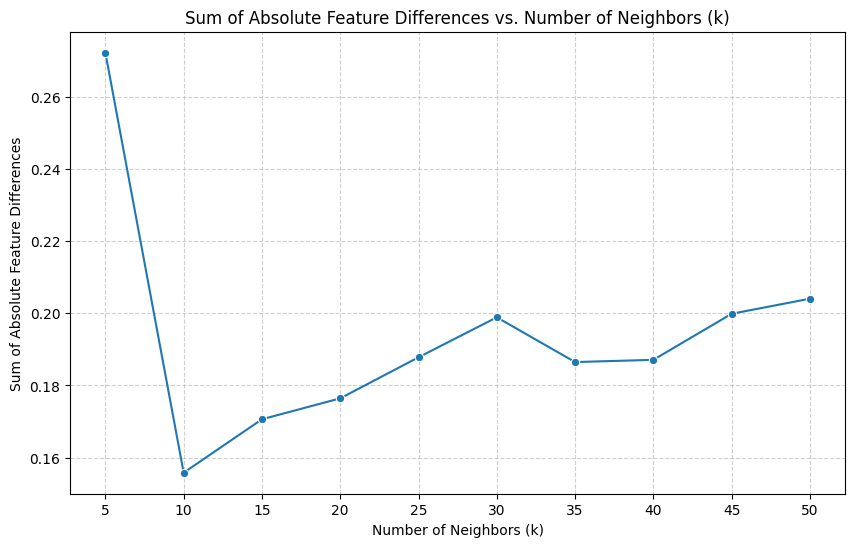

In [34]:

# Plotting the results
k_plot_df = pd.DataFrame([{'k': r['k'], 'sum_abs_diff': r['sum_abs_diff']} for r in results])

plt.figure(figsize=(10, 6))
sns.lineplot(x='k', y='sum_abs_diff', data=k_plot_df, marker='o')
plt.title('Sum of Absolute Feature Differences vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Sum of Absolute Feature Differences')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

###### 獲得best_k

In [35]:
best_k

10

In [36]:
# You might also want to compare this best k result with the previous KNN and Average Random results
# This would require re-running the KNN recommendation with the best_k and comparing the feature_difference
# with average_random_feature_difference_overall
print(f"\n--- Comparing with previous results using optimal k ({best_k}) ---")

# Rerun KNN with optimal k to get the specific feature_difference for comparison
# Note: recommended_tracks_knn was from num_recommendations=20
# We need to re-evaluate for best_k
distances_optimal_k, indices_optimal_k = model_knn.kneighbors(original_song_scaled_features, n_neighbors=best_k + 1)
recommended_indices_optimal_k = indices_optimal_k[0][1:]
recommended_tracks_optimal_k = df_recs_knn.iloc[recommended_indices_optimal_k]
average_recommended_features_optimal_k = recommended_tracks_optimal_k[numerical_features].mean()
feature_difference_optimal_k = (original_song_scaled_features - average_recommended_features_optimal_k).abs().T.squeeze()


--- Comparing with previous results using optimal k (10) ---


In [37]:

print(f"KNN 推薦的特徵差異 (Feature Difference - KNN Recommendations) with k={best_k}:")
display(feature_difference_optimal_k)
print(f"\n隨機推薦同類歌曲的平均特徵差異 (Average Feature Difference - {num_iterations} Same Genre Random Recommendations):")
# average_random_feature_difference_overall is already calculated in the previous cell and should be available
display(average_random_feature_difference_overall)

# Plotting comparison for optimal k
comparison_df_optimal_k = pd.DataFrame({
    f'KNN Recommendation (k={best_k})': feature_difference_optimal_k,
    'Average Random Recommendation (Same Genre)': average_random_feature_difference_overall
})


KNN 推薦的特徵差異 (Feature Difference - KNN Recommendations) with k=10:


,718
danceability,0.000610
energy,0.003201
loudness,0.036018
speechiness,0.008061
acousticness,0.033803
instrumentalness,0.000106
liveness,0.002851
valence,0.062929
tempo,0.002609
duration_minutes,0.005607



隨機推薦同類歌曲的平均特徵差異 (Average Feature Difference - 50 Same Genre Random Recommendations):


,0
danceability,0.150790
energy,0.343837
loudness,0.007209
speechiness,0.048003
acousticness,0.622628
instrumentalness,0.055759
liveness,0.068535
valence,0.054081
tempo,0.039568
duration_minutes,0.048422


###### 依照最好的K值，將推薦的平均屬性與原曲比較

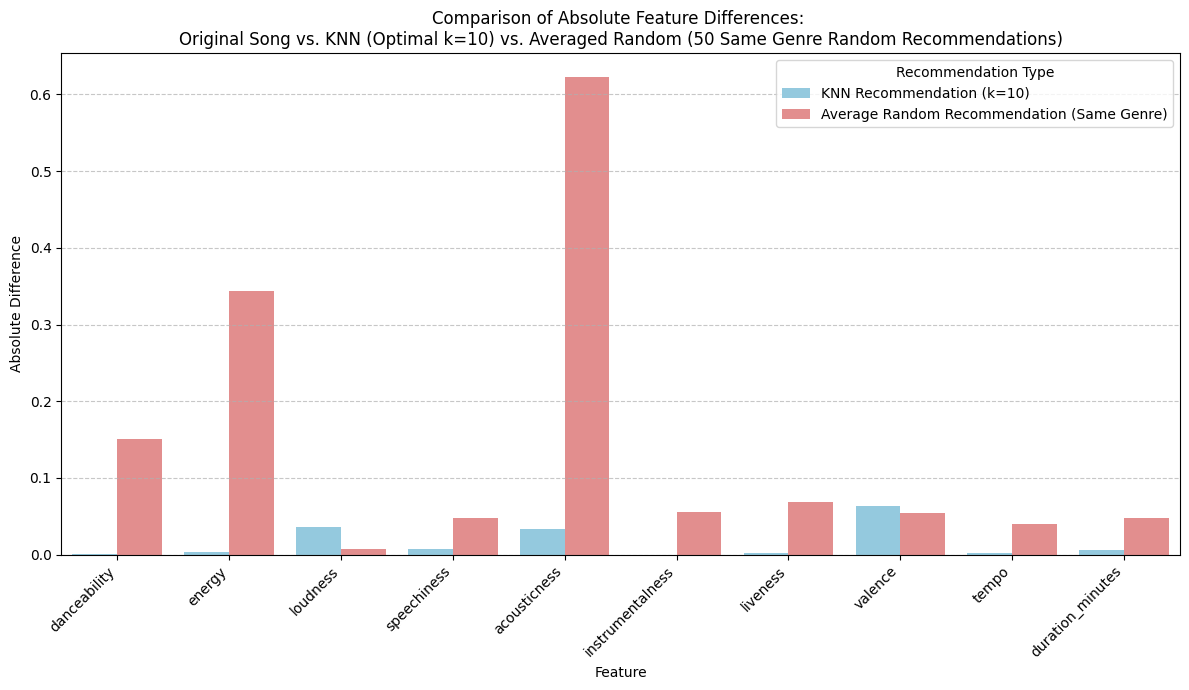

In [79]:
plt.figure(figsize=(12, 7))
sns.barplot(
    data=comparison_df_optimal_k.reset_index().melt(
        id_vars='index',
        var_name='Recommendation Type',
        value_name='Absolute Feature Difference'),
    x='index',
    y='Absolute Feature Difference',
    hue='Recommendation Type',
    palette={f'KNN Recommendation (k={best_k})': 'skyblue', 'Average Random Recommendation (Same Genre)': 'lightcoral'})

plt.title(f'Comparison of Absolute Feature Differences: \nOriginal Song vs. KNN (Optimal k={best_k}) vs. Averaged Random ({num_iterations} Same Genre Random Recommendations)')
plt.xlabel('Feature')
plt.ylabel('Absolute Difference')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###### 所有 `k` 值與平均隨機推薦的特徵差異綜合比較圖

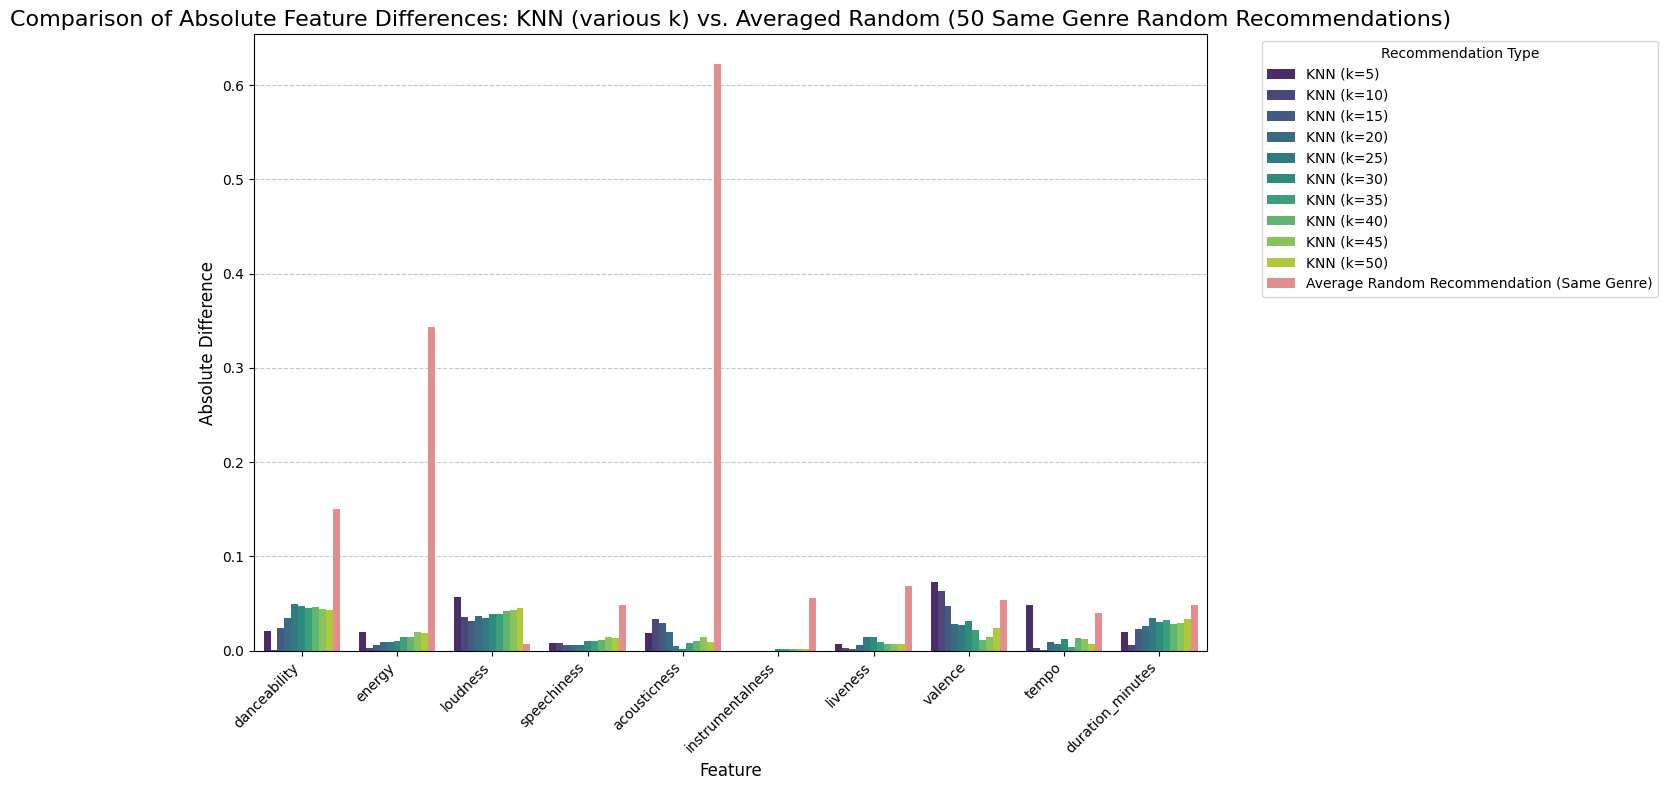

In [39]:
# Prepare data for a single plot
all_comparison_data = []

# Add KNN results for each k
for res in results:
    k = res['k']
    feature_difference_k = res['feature_difference']
    df_temp_knn = feature_difference_k.reset_index()
    df_temp_knn.columns = ['Feature', 'Absolute Difference']
    df_temp_knn['Recommendation Type'] = f'KNN (k={k})'
    all_comparison_data.append(df_temp_knn)

# Add Average Random Recommendation results
df_temp_random = average_random_feature_difference_overall.reset_index()
df_temp_random.columns = ['Feature', 'Absolute Difference']
df_temp_random['Recommendation Type'] = 'Average Random Recommendation (Same Genre)'
all_comparison_data.append(df_temp_random)

# Concatenate all dataframes
final_comparison_df = pd.concat(all_comparison_data)

# Define a custom color palette
k_colors = sns.color_palette("viridis", n_colors=len(k_values))
random_color = 'lightcoral'
palette = {f'KNN (k={k})': k_colors[i] for i, k in enumerate(k_values)}
palette['Average Random Recommendation (Same Genre)'] = random_color

plt.figure(figsize=(15, 8))
sns.barplot(
    data=final_comparison_df,
    x='Feature',
    y='Absolute Difference',
    hue='Recommendation Type',
    palette=palette,
    errorbar=None # To remove error bars if desired, as it's not applicable here
)

plt.title(f'Comparison of Absolute Feature Differences: KNN (various k) vs. Averaged Random ({num_iterations} Same Genre Random Recommendations)', fontsize=16)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Absolute Difference', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Recommendation Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='medium')
plt.tight_layout()
plt.show()

##### 3-4-3. 搜尋最佳Feature組合

In [41]:

# Original numerical features list
numerical_features_original = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_minutes',
]

# Define the range of k (number of neighbors) to search
k_values = range(5, 51, 5) # Test k from 5 to 50 with step 5

# --- Define candidate feature sets to test ---
candidate_feature_sets = []

# 1. Full original set
candidate_feature_sets.append(('Full Set', numerical_features_original))

# 2. Removing 'speechiness' (often very low or high depending on song type, can skew similarity)
features_no_speechiness = [f for f in numerical_features_original if f != 'speechiness']
candidate_feature_sets.append(('No Speechiness', features_no_speechiness))

# 3. Removing 'instrumentalness' (can be 0 for vocal tracks, 1 for instrumental, might over-emphasize this binary aspect)
features_no_instrumentalness = [f for f in numerical_features_original if f != 'instrumentalness']
candidate_feature_sets.append(('No Instrumentalness', features_no_instrumentalness))

# 4. Core 'mood' related features
features_mood_rhythm = ['danceability', 'energy', 'valence', 'liveness', 'tempo']
candidate_feature_sets.append(('Mood/Rhythm Core', features_mood_rhythm))

# 5. Acoustic vs Electronic focus (remove acousticness and instrumentalness)
features_no_acoustic_inst = [f for f in numerical_features_original if f not in ['acousticness', 'instrumentalness']]
candidate_feature_sets.append(('No Acoustic/Instrumental', features_no_acoustic_inst))

# 6. Minimal set for efficiency (e.g., just key emotional/rhythmic features)
features_minimal = ['danceability', 'energy', 'valence', 'loudness', 'tempo']
candidate_feature_sets.append(('Minimal Set', features_minimal))

# --- Perform Grid Search for each feature set ---
all_feature_set_results = []

print("Starting Grid Search for optimal feature sets and k values...")

for feature_set_name, current_features in candidate_feature_sets:
    print(f"\n--- Testing Feature Set: {feature_set_name} ({len(current_features)} features) ---")

    # 1. Re-scale data for *current_features*
    # Create a new scaler for each feature set to ensure proper 0-1 scaling for only these features
    temp_scaler = MinMaxScaler()
    df_current_scaled_array = temp_scaler.fit_transform(df_recs_knn[current_features])
    df_current_scaled_df = pd.DataFrame(df_current_scaled_array, columns=current_features, index=df_recs_knn.index)

    # 2. Extract original song's scaled features for *current_features*
    # Use the same scaler to transform the original song's features
    original_song_features_for_scaling = df_recs_knn.loc[[original_song_info.name]][current_features]
    original_song_scaled_features_current = pd.DataFrame(
        temp_scaler.transform(original_song_features_for_scaling),
        columns=current_features,
        index=original_song_features_for_scaling.index
    )

    # 3. Train KNN model for *current_features*
    model_knn_current = NearestNeighbors(metric='cosine', algorithm='brute')
    model_knn_current.fit(df_current_scaled_df)

    # 4. Perform Grid Search for k using *current_features*
    inner_results = []
    for k in k_values:
        # Find the nearest neighbors for the original song (k+1 to exclude itself)
        distances, indices = model_knn_current.kneighbors(original_song_scaled_features_current, n_neighbors=k + 1)

        # Get the indices of the recommended songs (excluding the original song itself)
        recommended_indices = indices[0][1:]

        # Get the recommended tracks using the scaled DataFrame
        recommended_tracks_k_current = df_current_scaled_df.iloc[recommended_indices]

        # Calculate Average Features of Recommended Tracks
        average_recommended_features_k_current = recommended_tracks_k_current[current_features].mean()

        # Calculate Feature Difference (Original vs. Average Recommended)
        feature_difference_k_current = (original_song_scaled_features_current - average_recommended_features_k_current).abs().T.squeeze()

        # Calculate a single metric for evaluation, e.g., sum of absolute differences
        sum_abs_diff_current = feature_difference_k_current.sum()
        inner_results.append({'k': k, 'sum_abs_diff': sum_abs_diff_current})

    # Find the best k for this feature set
    best_inner_result = min(inner_results, key=lambda x: x['sum_abs_diff'])
    best_k_for_this_set = best_inner_result['k']
    min_sum_abs_diff_for_this_set = best_inner_result['sum_abs_diff']

    print(f"  Optimal k for this set: {best_k_for_this_set} with min sum_abs_diff = {min_sum_abs_diff_for_this_set:.4f}")

    # 5. Store results for *this feature set*
    all_feature_set_results.append({
        'feature_set_name': feature_set_name,
        'features_count': len(current_features),
        'best_k': best_k_for_this_set,
        'min_sum_abs_diff': min_sum_abs_diff_for_this_set,
        'features': current_features # Store the actual list of features for reference
    })




Starting Grid Search for optimal feature sets and k values...

--- Testing Feature Set: Full Set (10 features) ---
  Optimal k for this set: 10 with min sum_abs_diff = 0.1558

--- Testing Feature Set: No Speechiness (9 features) ---
  Optimal k for this set: 10 with min sum_abs_diff = 0.1759

--- Testing Feature Set: No Instrumentalness (9 features) ---
  Optimal k for this set: 15 with min sum_abs_diff = 0.1649

--- Testing Feature Set: Mood/Rhythm Core (5 features) ---
  Optimal k for this set: 5 with min sum_abs_diff = 0.5957

--- Testing Feature Set: No Acoustic/Instrumental (8 features) ---
  Optimal k for this set: 25 with min sum_abs_diff = 0.1403

--- Testing Feature Set: Minimal Set (5 features) ---
  Optimal k for this set: 50 with min sum_abs_diff = 0.1471


In [42]:
# --- Final Analysis ---
print("\n--- Overall Best Feature Set ---")
overall_best_result = min(all_feature_set_results, key=lambda x: x['min_sum_abs_diff'])

print(f"Overall Best Feature Set: '{overall_best_result['feature_set_name']}'")
print(f"Number of Features: {overall_best_result['features_count']}")
print(f"Best k: {overall_best_result['best_k']}")
print(f"Minimum Sum of Absolute Feature Differences: {overall_best_result['min_sum_abs_diff']:.4f}")
print(f"Features used: {overall_best_result['features']}")


--- Overall Best Feature Set ---
Overall Best Feature Set: 'No Acoustic/Instrumental'
Number of Features: 8
Best k: 25
Minimum Sum of Absolute Feature Differences: 0.1403
Features used: ['danceability', 'energy', 'loudness', 'speechiness', 'liveness', 'valence', 'tempo', 'duration_minutes']



Detailed results for all feature sets:


,feature_set_name,features_count,best_k,min_sum_abs_diff,features
4,No Acoustic/Instrumental,8,25,0.140272,"[danceability, energy, loudness, speechiness, ..."
5,Minimal Set,5,50,0.147148,"[danceability, energy, valence, loudness, tempo]"
0,Full Set,10,10,0.155795,"[danceability, energy, loudness, speechiness, ..."
2,No Instrumentalness,9,15,0.164876,"[danceability, energy, loudness, speechiness, ..."
1,No Speechiness,9,10,0.175916,"[danceability, energy, loudness, acousticness,..."
3,Mood/Rhythm Core,5,5,0.595736,"[danceability, energy, valence, liveness, tempo]"


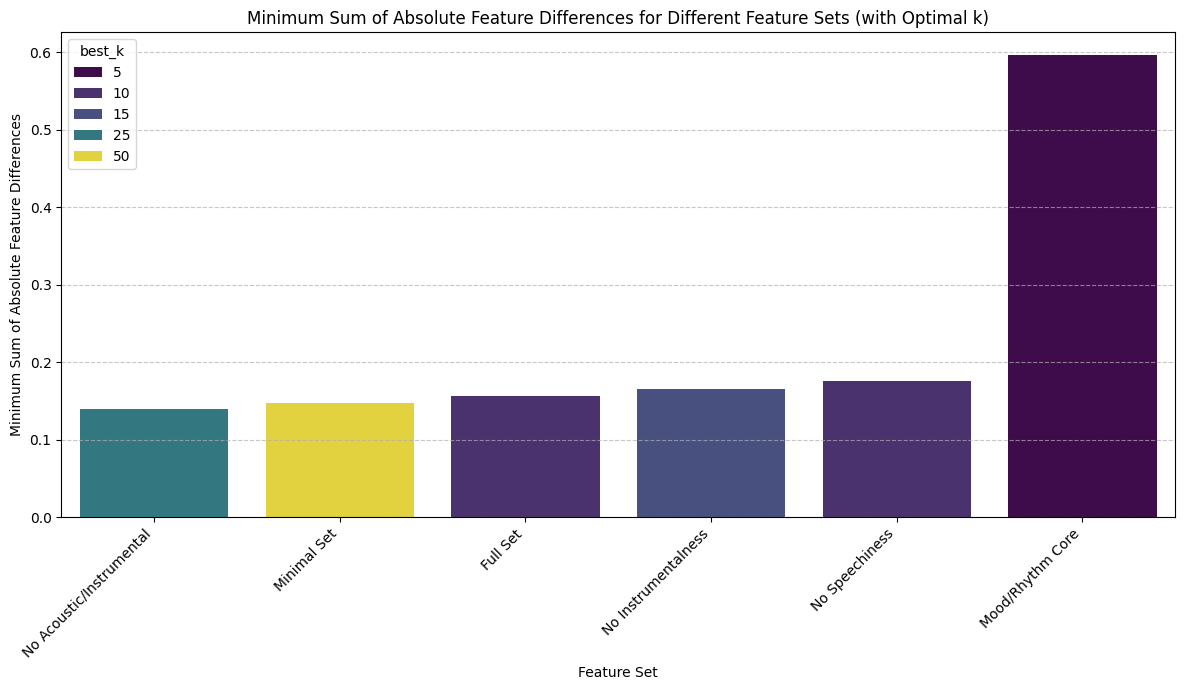

In [43]:
# Optionally, display all results in a DataFrame for easier comparison
results_df = pd.DataFrame(all_feature_set_results).sort_values(by='min_sum_abs_diff')
print("\nDetailed results for all feature sets:")
display(results_df)

# Plotting the results
plt.figure(figsize=(12, 7))
sns.barplot(x='feature_set_name', y='min_sum_abs_diff', hue='best_k', data=results_df, palette='viridis')
plt.title('Minimum Sum of Absolute Feature Differences for Different Feature Sets (with Optimal k)')
plt.xlabel('Feature Set')
plt.ylabel('Minimum Sum of Absolute Feature Differences')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Overall Best Feature Set ---
* Overall Best Feature Set: **'No Acoustic/Instrumental'**
* Number of Features: **8**
* Best k: **25**
* Minimum Sum of Absolute Feature Differences: **0.1403**
* Features used: ['danceability', 'energy', 'loudness', 'speechiness', 'liveness', 'valence', 'tempo', 'duration_minutes']

### 4.Overall Testing

In [45]:
# Ensure `overall_best_result` is available. It should be from cell `oyWJhv8vmZKi`.
# If not, use the fallback values from the previous successful run.
if 'overall_best_result' not in locals():
    overall_best_result = {
        'feature_set_name': 'No Acoustic/Instrumental',
        'features_count': 8,
        'best_k': 25,
        'min_sum_abs_diff': 0.1403,
        'features': ['danceability', 'energy', 'loudness', 'speechiness', 'liveness', 'valence', 'tempo', 'duration_minutes']
    }

best_features_for_recs = overall_best_result['features']
optimal_k_for_recs = overall_best_result['best_k']

print(f"Using best feature set: {overall_best_result['feature_set_name']} with features: {best_features_for_recs}")
print(f"Using optimal k: {optimal_k_for_recs}")

Using best feature set: No Acoustic/Instrumental with features: ['danceability', 'energy', 'loudness', 'speechiness', 'liveness', 'valence', 'tempo', 'duration_minutes']
Using optimal k: 25


In [46]:
# 1. Re-scale data using the best feature set (if not already done with these specific features)
# It's safer to re-initialize and fit the scaler to the `best_features_for_recs` each time
scaler_optimal = MinMaxScaler()
df_recs_knn_optimal_scaled = df_recs_knn.copy()
df_recs_knn_optimal_scaled[best_features_for_recs] = scaler_optimal.fit_transform(df_recs_knn[best_features_for_recs])

# 2. Train KNN model using the best feature set
model_knn_optimal = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn_optimal.fit(df_recs_knn_optimal_scaled[best_features_for_recs])

NearestNeighbors(algorithm='brute', metric='cosine')

In [47]:
# Define the recommendation function to be used within the loop
def recommend_songs_knn_for_evaluation(song_index, dataframe, model, scaler, feature_list, num_recommendations):
    # Get the original song's unscaled features by index
    # Use .loc as song_index will be an index label from df_recs_knn.index
    song_features_unscaled = dataframe[feature_list].loc[[song_index]]

    # Scale the original song's features using the trained scaler
    song_features_scaled = pd.DataFrame(
        scaler.transform(song_features_unscaled),
        columns=feature_list,
        index=song_features_unscaled.index
    )

    # Find the nearest neighbors
    distances, indices = model.kneighbors(song_features_scaled, n_neighbors=num_recommendations + 1)

    # Flatten the arrays and get recommended indices (excluding the song itself)
    # These indices are positional (iloc-based) relative to the trained model's data
    recommended_indices = indices.flatten()[1:]

    # Get the recommended tracks' scaled features for averaging
    # Use .iloc because recommended_indices are positional indices returned by kneighbors
    recommended_tracks_scaled_features = df_recs_knn_optimal_scaled.iloc[recommended_indices][feature_list]

    # Calculate average features of recommended tracks
    average_recommended_features = recommended_tracks_scaled_features.mean()

    # Calculate feature difference (Original SCALED vs. Average Recommended SCALED)
    # Ensure original_song_scaled_features is a Series for subtraction
    feature_difference = (song_features_scaled.iloc[0] - average_recommended_features).abs()
    return feature_difference

##### 4-1.重複做推薦100次來當作總提評估

In [66]:
# --- User Request: Evaluate 100 original songs ---
num_original_songs_to_test = 100

# Randomly select 100 original songs from the dataset (using indices)
np.random.seed(42) # for reproducibility
random_original_song_indices = np.random.choice(df_recs_knn.index, num_original_songs_to_test, replace=False)

all_overall_feature_differences = []

print(f"\nEvaluating average feature differences for {num_original_songs_to_test} random original songs...")

for i, song_idx in enumerate(random_original_song_indices):
    # Calculate feature differences for each song
    feature_diff = recommend_songs_knn_for_evaluation(
        song_idx,
        df_recs_knn, # Pass the original df_recs_knn for metadata and finding song by name
        model_knn_optimal,
        scaler_optimal,
        best_features_for_recs,
        num_recommendations=optimal_k_for_recs
    )
    all_overall_feature_differences.append(feature_diff)
    if (i + 1) % 10 == 0: # Print progress
        print(f"  Processed {i+1}/{num_original_songs_to_test} songs...")

# Average the feature differences over all 100 original songs
average_feature_difference_100_songs = pd.DataFrame(all_overall_feature_differences).mean()
print(f"\n--- Average Feature Differences across {num_original_songs_to_test} Original Songs ---")
display(average_feature_difference_100_songs)


Evaluating average feature differences for 100 random original songs...
  Processed 10/100 songs...
  Processed 20/100 songs...
  Processed 30/100 songs...
  Processed 40/100 songs...
  Processed 50/100 songs...
  Processed 60/100 songs...
  Processed 70/100 songs...
  Processed 80/100 songs...
  Processed 90/100 songs...
  Processed 100/100 songs...

--- Average Feature Differences across 100 Original Songs ---


,0
danceability,0.029712
energy,0.027598
loudness,0.028235
speechiness,0.017136
liveness,0.017724
valence,0.022736
tempo,0.023744
duration_minutes,0.025439


In [67]:
print(f"\n--- Comparison with previous {num_iterations} Same Genre Random Recommendations (from 'Someone You Loved') ---")
display(average_random_feature_difference_overall)

# Plotting the comparison
comparison_df_overall = pd.DataFrame({
    f'KNN Recommendations (Avg over {num_original_songs_to_test} songs)': average_feature_difference_100_songs,
    f'Average Random Recommendation (50 iterations for 1 song)': average_random_feature_difference_overall
})

display(comparison_df_overall)


--- Comparison with previous 50 Same Genre Random Recommendations (from 'Someone You Loved') ---


,0
danceability,0.150790
energy,0.343837
loudness,0.007209
speechiness,0.048003
acousticness,0.622628
instrumentalness,0.055759
liveness,0.068535
valence,0.054081
tempo,0.039568
duration_minutes,0.048422


,KNN Recommendations (Avg over 100 songs),Average Random Recommendation (50 iterations for 1 song)
acousticness,NaN,0.622628
danceability,0.029712,0.150790
duration_minutes,0.025439,0.048422
energy,0.027598,0.343837
instrumentalness,NaN,0.055759
liveness,0.017724,0.068535
loudness,0.028235,0.007209
speechiness,0.017136,0.048003
tempo,0.023744,0.039568
valence,0.022736,0.054081


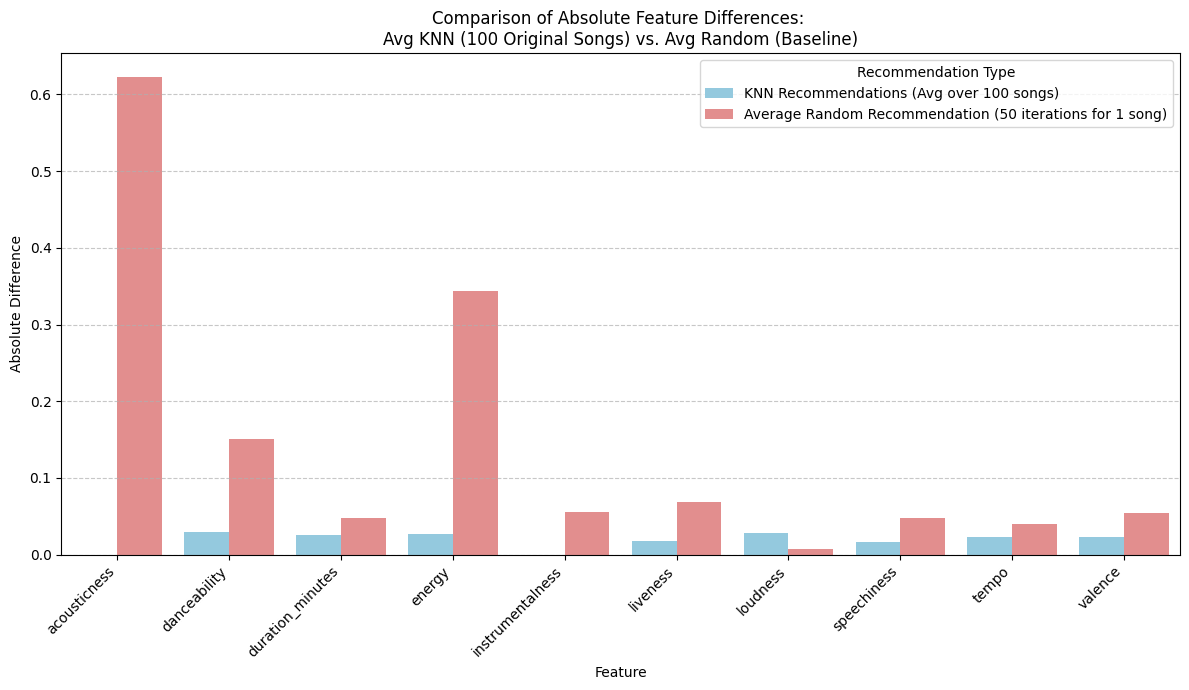

In [71]:

plt.figure(figsize=(12, 7))
sns.barplot(
    data=comparison_df_overall.reset_index().melt(
        id_vars='index',
        var_name='Recommendation Type',
        value_name='Absolute Feature Difference'),
    x='index',
    y='Absolute Feature Difference',
    hue='Recommendation Type',
    palette={'KNN Recommendations (Avg over 100 songs)': 'skyblue', 'Average Random Recommendation (50 iterations for 1 song)': 'lightcoral'}
)

plt.title(f'Comparison of Absolute Feature Differences: \nAvg KNN (100 Original Songs) vs. Avg Random (Baseline)')
plt.xlabel('Feature')
plt.ylabel('Absolute Difference')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 4-2.畫總圖

In [81]:
num_original_songs_to_test = 100
random_original_song_indices = np.random.choice(df_recs_knn.index, num_original_songs_to_test, replace=False)

In [82]:
# --- Re-using optimal parameters from previous analysis ---
# `best_features_for_recs`, `optimal_k_for_recs`, `scaler_optimal`, `model_knn_optimal`,
# `df_recs_knn_optimal_scaled`, `num_original_songs_to_test`, `random_original_song_indices`
# should be available from previous cells. If not, re-run them.

# --- 1. Calculate Average Random Feature Difference (across 100 original songs) ---
all_random_feature_differences_100_songs = []
print(f"\nCalculating average feature differences for {num_original_songs_to_test} random recommendations...")

for i, song_idx in enumerate(random_original_song_indices):
    # Get the original song's scaled numerical features for the current song
    original_song_scaled_features_current = df_recs_knn_optimal_scaled.loc[[song_idx]][best_features_for_recs]

    # Generate random recommendations (from the entire dataset)
    num_recs_for_random = optimal_k_for_recs # Use optimal_k for consistency
    random_indices = np.random.choice(df_recs_knn_optimal_scaled.index, num_recs_for_random, replace=False)
    random_tracks_scaled_features = df_recs_knn_optimal_scaled.loc[random_indices][best_features_for_recs]

    # Calculate Average Features of Random Recommendations
    average_random_features = random_tracks_scaled_features.mean()

    # Calculate Feature Difference (Original SCALED vs. Average Random SCALED)
    feature_difference_random = (original_song_scaled_features_current.iloc[0] - average_random_features).abs()
    all_random_feature_differences_100_songs.append(feature_difference_random)

average_random_feature_difference_100_songs = pd.DataFrame(all_random_feature_differences_100_songs).mean()
print(f"  Average Random Feature Difference (over {num_original_songs_to_test} songs) calculated.")


Calculating average feature differences for 100 random recommendations...
  Average Random Feature Difference (over 100 songs) calculated.


In [83]:
# --- 2. Calculate Average Same-Genre Random Feature Difference (across 100 original songs) ---
all_same_genre_random_feature_differences_100_songs = []
print(f"\nCalculating average feature differences for {num_original_songs_to_test} same-genre random recommendations...")

for i, song_idx in enumerate(random_original_song_indices):
    # Get the original song's info to find its genre
    original_song_info_current = df.loc[song_idx] # Use original df for genre info
    original_genre_current = original_song_info_current['playlist_genre']
    original_subgenre_current = original_song_info_current['playlist_subgenre']

    # Get the original song's scaled numerical features for the current song
    original_song_scaled_features_current = df_recs_knn_optimal_scaled.loc[[song_idx]][best_features_for_recs]

    # Filter for same genre/subgenre songs in the scaled dataframe
    same_genre_indices_scaled = df_recs_knn_optimal_scaled[
        (df_recs_knn_optimal_scaled['playlist_genre'] == original_genre_current) &
        (df_recs_knn_optimal_scaled['playlist_subgenre'] == original_subgenre_current)
    ].index

    # Ensure there are enough songs in the same genre/subgenre to pick from
    if len(same_genre_indices_scaled) < num_recs_for_random:
        # Fallback if not enough songs (e.g., use all available or broader genre)
        # For now, just skip if not enough to avoid errors, or choose less if replace=False
        # Or, we can set replace=True if we allow picking same song multiple times, but it might skew results.
        # Let's make it so it still works, but potentially with replacement if needed.
        replace_mode = True if len(same_genre_indices_scaled) < num_recs_for_random else False
        random_same_genre_indices = np.random.choice(same_genre_indices_scaled, num_recs_for_random, replace=replace_mode)
    else:
        random_same_genre_indices = np.random.choice(same_genre_indices_scaled, num_recs_for_random, replace=False)

    random_same_genre_tracks_scaled_features = df_recs_knn_optimal_scaled.loc[random_same_genre_indices][best_features_for_recs]

    # Calculate Average Features of Same-Genre Random Recommendations
    average_same_genre_random_features = random_same_genre_tracks_scaled_features.mean()

    # Calculate Feature Difference (Original SCALED vs. Average Same-Genre Random SCALED)
    feature_difference_same_genre_random = (original_song_scaled_features_current.iloc[0] - average_same_genre_random_features).abs()
    all_same_genre_random_feature_differences_100_songs.append(feature_difference_same_genre_random)

average_same_genre_random_feature_difference_100_songs = pd.DataFrame(all_same_genre_random_feature_differences_100_songs).mean()
print(f"  Average Same-Genre Random Feature Difference (over {num_original_songs_to_test} songs) calculated.")


Calculating average feature differences for 100 same-genre random recommendations...
  Average Same-Genre Random Feature Difference (over 100 songs) calculated.


In [84]:
# --- 3. Plotting the Comparison ---
print("\n--- Displaying Comparison Plot ---")

# Combine all three average feature differences into a single DataFrame for plotting
comparison_df_final = pd.DataFrame({
    f'KNN Recs (Avg over {num_original_songs_to_test} songs)': average_feature_difference_100_songs,
    f'Random Recs (Avg over {num_original_songs_to_test} songs)': average_random_feature_difference_100_songs,
    f'Same Genre Random Recs (Avg over {num_original_songs_to_test} songs)': average_same_genre_random_feature_difference_100_songs
})


--- Displaying Comparison Plot ---


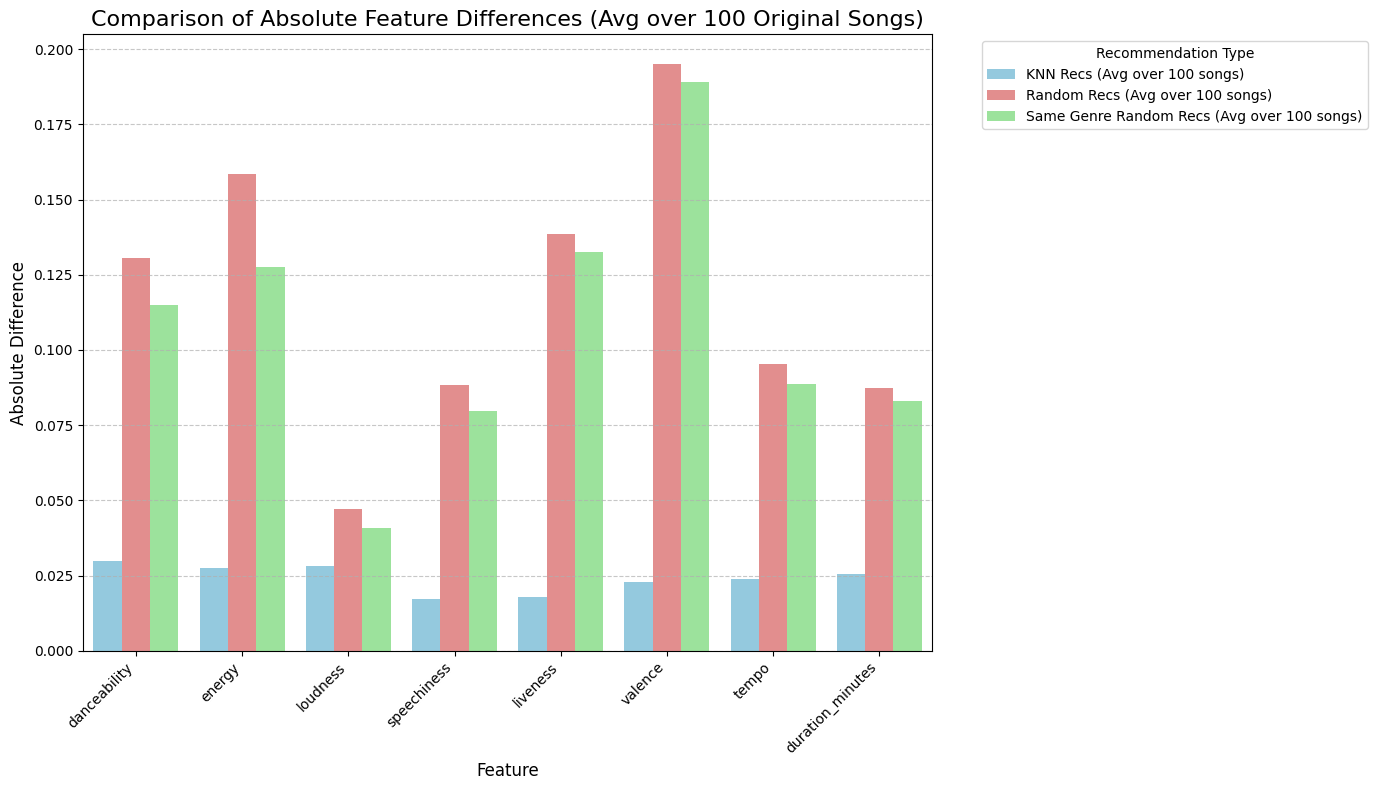

In [85]:
plt.figure(figsize=(14, 8))
sns.barplot(
    data=comparison_df_final.reset_index().melt(
        id_vars='index',
        var_name='Recommendation Type',
        value_name='Absolute Feature Difference'),
    x='index',
    y='Absolute Feature Difference',
    hue='Recommendation Type',
    palette={'KNN Recs (Avg over 100 songs)': 'skyblue',
             'Random Recs (Avg over 100 songs)': 'lightcoral',
             'Same Genre Random Recs (Avg over 100 songs)': 'lightgreen'}
)

plt.title(f'Comparison of Absolute Feature Differences (Avg over {num_original_songs_to_test} Original Songs)', fontsize=16)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Absolute Difference', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Recommendation Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='medium')
plt.tight_layout()
plt.show()

## 5.總體參數再度調整

In [53]:
# Ensure `df_recs_knn_optimal_scaled` is correctly set up from previous cells
# Re-scale data using the best feature set
scaler_optimal = MinMaxScaler()
df_recs_knn_optimal_scaled = df_recs_knn.copy()
df_recs_knn_optimal_scaled[best_features_for_recs] = scaler_optimal.fit_transform(df_recs_knn[best_features_for_recs])

# Get the original song's scaled features for evaluation. Assuming 'Someone You Loved' is the reference.
# Ensure `original_song_name` and `original_song_info` are available.
if 'original_song_name' not in locals():
    original_song_name = 'Someone You Loved'
    # Assuming `df` is the raw dataframe, get its info
    original_song_info = df[df['track_name'] == original_song_name].iloc[0]

original_song_scaled_features_optimal = df_recs_knn_optimal_scaled.loc[[original_song_info.name]][best_features_for_recs]

print(f"Evaluating algorithms and 'k' for recommendation using manual Grid Search for original song: '{original_song_name}'")
print(f"Using feature set: {best_features_for_recs}")

Evaluating algorithms and 'k' for recommendation using manual Grid Search for original song: 'Someone You Loved'
Using feature set: ['danceability', 'energy', 'loudness', 'speechiness', 'liveness', 'valence', 'tempo', 'duration_minutes']


##### 5-1.調整距離計算參數

In [54]:

# Manual Grid Search instead of GridSearchCV due to custom scoring complexities for unsupervised models
all_grid_results = []

# Define the parameter combinations
param_combinations = []
k_values = range(5, 51, 5)

for k_val in k_values:
    # Brute force with both metrics
    param_combinations.append({'n_neighbors': k_val, 'algorithm': 'brute', 'metric': 'cosine'})
    param_combinations.append({'n_neighbors': k_val, 'algorithm': 'brute', 'metric': 'euclidean'})

print("\nStarting manual Grid Search for NearestNeighbors algorithms, k, and metrics...")

for i, params in enumerate(param_combinations):
    n_neighbors = params['n_neighbors']
    algorithm = params['algorithm']
    metric = params['metric']

    print(f"  ({i+1}/{len(param_combinations)}) Testing: k={n_neighbors}, algorithm={algorithm}, metric={metric}")

    # 1. Instantiate and fit NearestNeighbors model on the *entire* dataset
    # This is crucial for the custom scorer to work as intended for a fixed query song
    current_model_knn = NearestNeighbors(
        n_neighbors=n_neighbors,
        algorithm=algorithm,
        metric=metric)
    current_model_knn.fit(df_recs_knn_optimal_scaled[best_features_for_recs])

    # 2. Apply the custom scoring logic
    # Get the indices of the neighbors for the original song (n_neighbors + 1 to exclude itself)
    distances, indices = current_model_knn.kneighbors(
        original_song_scaled_features_optimal,
        n_neighbors=n_neighbors + 1
    )

    # Get the recommended tracks' scaled features (excluding the original song itself)
    recommended_indices_in_X = indices[0][1:] # indices refer to the rows in the *fitted* data

    # Get the actual data points from the full scaled DataFrame
    recommended_tracks_scaled_features = df_recs_knn_optimal_scaled.iloc[recommended_indices_in_X][best_features_for_recs]

    # Calculate average features of recommended tracks
    average_recommended_features = recommended_tracks_scaled_features.mean()

    # Calculate feature difference (Original SCALED vs. Average Recommended SCALED)
    feature_difference = (original_song_scaled_features_optimal.iloc[0] - average_recommended_features).abs()

    # The score is the sum of absolute differences (lower is better)
    sum_abs_diff = feature_difference.sum()

    all_grid_results.append({
        'n_neighbors': n_neighbors,
        'algorithm': algorithm,
        'metric': metric,
        'sum_abs_diff': sum_abs_diff
    })



Starting manual Grid Search for NearestNeighbors algorithms, k, and metrics...
  (1/20) Testing: k=5, algorithm=brute, metric=cosine
  (2/20) Testing: k=5, algorithm=brute, metric=euclidean
  (3/20) Testing: k=10, algorithm=brute, metric=cosine
  (4/20) Testing: k=10, algorithm=brute, metric=euclidean
  (5/20) Testing: k=15, algorithm=brute, metric=cosine
  (6/20) Testing: k=15, algorithm=brute, metric=euclidean
  (7/20) Testing: k=20, algorithm=brute, metric=cosine
  (8/20) Testing: k=20, algorithm=brute, metric=euclidean
  (9/20) Testing: k=25, algorithm=brute, metric=cosine
  (10/20) Testing: k=25, algorithm=brute, metric=euclidean
  (11/20) Testing: k=30, algorithm=brute, metric=cosine
  (12/20) Testing: k=30, algorithm=brute, metric=euclidean
  (13/20) Testing: k=35, algorithm=brute, metric=cosine
  (14/20) Testing: k=35, algorithm=brute, metric=euclidean
  (15/20) Testing: k=40, algorithm=brute, metric=cosine
  (16/20) Testing: k=40, algorithm=brute, metric=euclidean
  (17/20) T

In [55]:

# Convert results to DataFrame for easier analysis and plotting
results_df_algo_k = pd.DataFrame(all_grid_results)

# Find the best parameters
best_result_manual = results_df_algo_k.loc[results_df_algo_k['sum_abs_diff'].idxmin()]

print("\n--- Manual Grid Search Results ---")
print(f"Best parameters found: {best_result_manual.drop('sum_abs_diff').to_dict()}")
print(f"Best sum of absolute differences: {best_result_manual['sum_abs_diff']:.4f}")

# Display detailed results, sorted by sum_abs_diff (lower is better)
display(results_df_algo_k.sort_values(by='sum_abs_diff'))


--- Manual Grid Search Results ---
Best parameters found: {'n_neighbors': 15, 'algorithm': 'brute', 'metric': 'euclidean'}
Best sum of absolute differences: 0.1349


,n_neighbors,algorithm,metric,sum_abs_diff
5,15,brute,euclidean,0.134852
3,10,brute,euclidean,0.138227
8,25,brute,cosine,0.140272
10,30,brute,cosine,0.141371
6,20,brute,cosine,0.148821
12,35,brute,cosine,0.151259
4,15,brute,cosine,0.154336
18,50,brute,cosine,0.162329
14,40,brute,cosine,0.162473
16,45,brute,cosine,0.163649


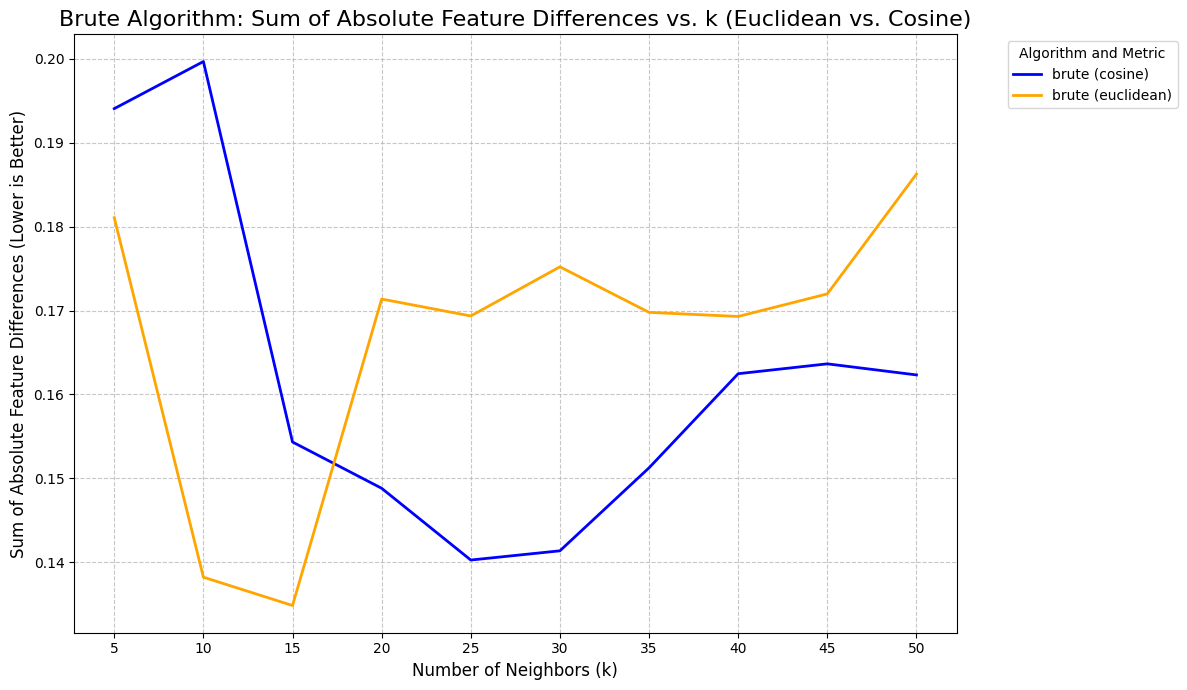

In [59]:
# --- Plot 1: Brute Algorithm Performance ---

brute_df = results_df_algo_k[results_df_algo_k['algorithm'] == 'brute'].copy()

# Define custom palette for brute algorithm to ensure 'brute (euclidean)' is orange
custom_palette_brute = {
    'brute (euclidean)': 'orange',
    'brute (cosine)': 'blue'
}

brute_df['Algorithm_Metric'] = brute_df['algorithm'] + ' (' + brute_df['metric'] + ')'

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=brute_df,
    x='n_neighbors',
    y='sum_abs_diff',
    hue='Algorithm_Metric',
    markers=True,
    palette=custom_palette_brute,
    linewidth=2
)
plt.title('Brute Algorithm: Sum of Absolute Feature Differences vs. k (Euclidean vs. Cosine)', fontsize=16)
plt.xlabel('Number of Neighbors (k)', fontsize=12)
plt.ylabel('Sum of Absolute Feature Differences (Lower is Better)', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Algorithm and Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [73]:
# Ensure necessary variables are available from previous cells
# df_recs_knn_optimal_scaled, best_features_for_recs, num_original_songs_to_test,
# and random_original_song_indices should be in the kernel state.

num_original_songs_to_test = 500
random_original_song_indices = np.random.choice(df_recs_knn.index, num_original_songs_to_test, replace=False)
# Define the parameter combinations
all_grid_results_per_song = [] # To store results for each song and each param combination
k_values = range(5, 51, 5)

param_combinations_for_grid = []
for k_val in k_values:
    param_combinations_for_grid.append({'n_neighbors': k_val, 'algorithm': 'brute', 'metric': 'cosine'})
    param_combinations_for_grid.append({'n_neighbors': k_val, 'algorithm': 'brute', 'metric': 'euclidean'})

print(f"Starting comprehensive Grid Search across {num_original_songs_to_test} random songs...")

# Loop through each randomly selected original song
for song_idx_counter, original_song_idx in enumerate(random_original_song_indices):
    # Get the original song's scaled features for the current song
    original_song_scaled_features_current = df_recs_knn_optimal_scaled.loc[[original_song_idx]][best_features_for_recs]

    # Loop through each parameter combination for the current song
    for params in param_combinations_for_grid:
        n_neighbors = params['n_neighbors']
        algorithm = params['algorithm']
        metric = params['metric']

        # Instantiate and fit NearestNeighbors model
        current_model_knn = NearestNeighbors(
            n_neighbors=n_neighbors,
            algorithm=algorithm,
            metric=metric)
        current_model_knn.fit(df_recs_knn_optimal_scaled[best_features_for_recs])

        # Get the indices of the neighbors for the original song (n_neighbors + 1 to exclude itself)
        distances, indices = current_model_knn.kneighbors(
            original_song_scaled_features_current,
            n_neighbors=n_neighbors + 1
        )

        # Get the recommended tracks' scaled features (excluding the original song itself)
        recommended_indices_in_X = indices[0][1:]
        recommended_tracks_scaled_features = df_recs_knn_optimal_scaled.iloc[recommended_indices_in_X][best_features_for_recs]

        # Calculate average features of recommended tracks
        average_recommended_features = recommended_tracks_scaled_features.mean()

        # Calculate feature difference (Original SCALED vs. Average Recommended SCALED)
        feature_difference = (original_song_scaled_features_current.iloc[0] - average_recommended_features).abs()

        # The score is the sum of absolute differences (lower is better)
        sum_abs_diff = feature_difference.sum()

        all_grid_results_per_song.append({
            'original_song_idx': original_song_idx,
            'n_neighbors': n_neighbors,
            'algorithm': algorithm,
            'metric': metric,
            'sum_abs_diff': sum_abs_diff
        })

    if (song_idx_counter + 1) % 10 == 0:
        print(f"  Processed {song_idx_counter+1}/{num_original_songs_to_test} songs...")


Starting comprehensive Grid Search across 500 random songs...
  Processed 10/500 songs...
  Processed 20/500 songs...
  Processed 30/500 songs...
  Processed 40/500 songs...
  Processed 50/500 songs...
  Processed 60/500 songs...
  Processed 70/500 songs...
  Processed 80/500 songs...
  Processed 90/500 songs...
  Processed 100/500 songs...
  Processed 110/500 songs...
  Processed 120/500 songs...
  Processed 130/500 songs...
  Processed 140/500 songs...
  Processed 150/500 songs...
  Processed 160/500 songs...
  Processed 170/500 songs...
  Processed 180/500 songs...
  Processed 190/500 songs...
  Processed 200/500 songs...
  Processed 210/500 songs...
  Processed 220/500 songs...
  Processed 230/500 songs...
  Processed 240/500 songs...
  Processed 250/500 songs...
  Processed 260/500 songs...
  Processed 270/500 songs...
  Processed 280/500 songs...
  Processed 290/500 songs...
  Processed 300/500 songs...
  Processed 310/500 songs...
  Processed 320/500 songs...
  Processed 330/500

In [86]:
# Convert results to DataFrame
results_df_per_song = pd.DataFrame(all_grid_results_per_song)

# Group by parameters and calculate the average sum_abs_diff across all songs
average_grid_results = results_df_per_song.groupby(['n_neighbors', 'algorithm', 'metric'])['sum_abs_diff'].mean().reset_index()

# Find the best parameters based on the average sum_abs_diff
best_avg_result = average_grid_results.loc[average_grid_results['sum_abs_diff'].idxmin()]

print("\n--- Average Grid Search Results (across all random songs) ---")
print(f"Best parameters found: {best_avg_result.drop('sum_abs_diff').to_dict()}")
print(f"Best average sum of absolute differences: {best_avg_result['sum_abs_diff']:.4f}")

# Display detailed results, sorted by average sum_abs_diff (lower is better)
print("\nDetailed average results for all parameter combinations:")
display(average_grid_results.sort_values(by='sum_abs_diff'))


# Plotting the results
brute_avg_df = average_grid_results[average_grid_results['algorithm'] == 'brute'].copy()
brute_avg_df['Algorithm_Metric'] = brute_avg_df['algorithm'] + ' (' + brute_avg_df['metric'] + ')'



--- Average Grid Search Results (across all random songs) ---
Best parameters found: {'n_neighbors': 10, 'algorithm': 'brute', 'metric': 'euclidean'}
Best average sum of absolute differences: 0.1447

Detailed average results for all parameter combinations:


,n_neighbors,algorithm,metric,sum_abs_diff
3,10,brute,euclidean,0.144694
5,15,brute,euclidean,0.146137
7,20,brute,euclidean,0.150068
1,5,brute,euclidean,0.150645
9,25,brute,euclidean,0.153254
11,30,brute,euclidean,0.158348
13,35,brute,euclidean,0.162252
15,40,brute,euclidean,0.165379
17,45,brute,euclidean,0.168824
19,50,brute,euclidean,0.172070


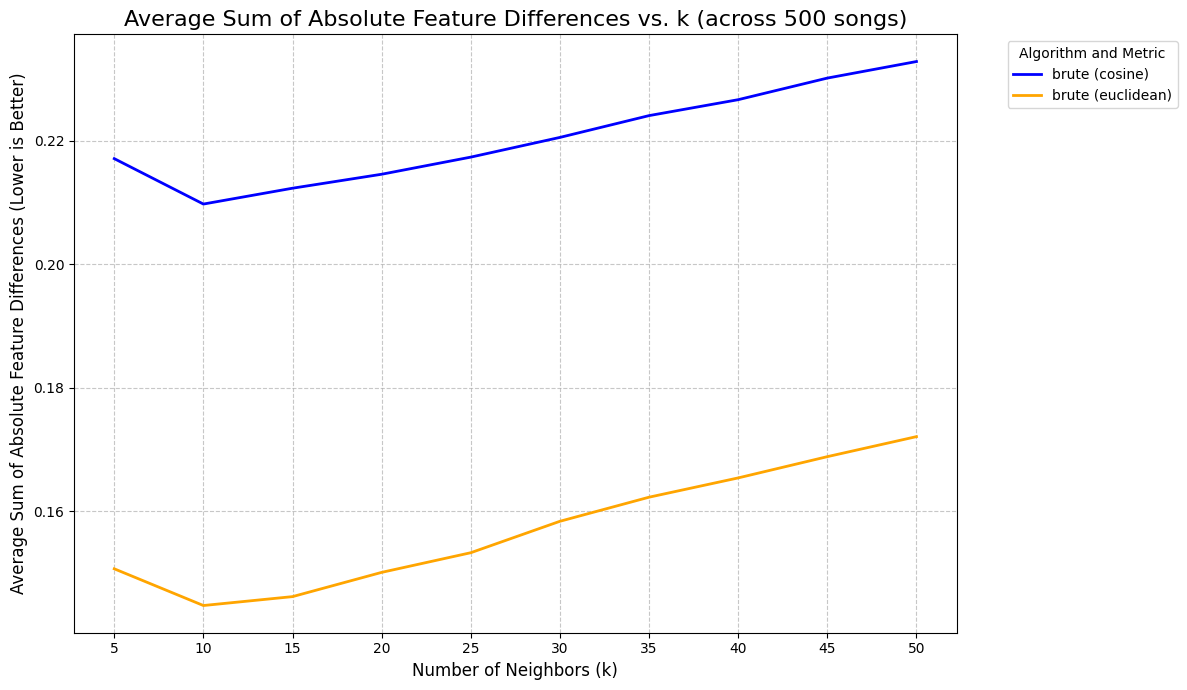

In [75]:
custom_palette_brute = {
    'brute (euclidean)': 'orange',
    'brute (cosine)': 'blue'
}

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=brute_avg_df,
    x='n_neighbors',
    y='sum_abs_diff',
    hue='Algorithm_Metric',
    markers=True,
    palette=custom_palette_brute,
    linewidth=2
)
plt.title(f'Average Sum of Absolute Feature Differences vs. k (across {num_original_songs_to_test} songs)', fontsize=16)
plt.xlabel('Number of Neighbors (k)', fontsize=12)
plt.ylabel('Average Sum of Absolute Feature Differences (Lower is Better)', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Algorithm and Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()